# Baseline evidence: real observing nights versus shuffled controls

This executable walkthrough asks whether a program-and-night label
captures repeatable structure in DESI stellar radial-velocity
differences. It uses only the compact CSV files committed to this
repository: no network access and no raw FITS files.

## tl;dr

- Across five held-out folds, the mean raw robust-scatter reduction
  is **0.494756 km/s**, from **3.651302** to **3.156547 km/s**
  (**13.55%**).
- The mean reductions from **100 shuffled-night controls** range
  from **0.071803** to **0.293896 km/s**. None reaches the real
  result, so the add-one empirical p-value is **1/101 = 0.009901**.
- Two disjoint source halves recover **483** common
  PROGRAM:NIGHT offsets with Pearson correlation **r = 0.98026**
  (slope **1.00157**).
- **Source-disjoint means different stars are used for training and
  testing on nights represented in the data.** It does not mean the
  model predicts a completely new observing night.

These checks support a transferable night-associated diagnostic.
They do not identify a physical cause and do not define an official
catalogue correction.


## Context & Methods

A star observed more than once should give compatible radial
velocities after accounting for uncertainty. Here, *robust scatter*
is a width summary designed to be less dominated by extreme pairs
than an ordinary standard deviation. A positive gain means the
held-out differences became narrower after applying offsets learned
from other sources.

A *fold* is one train/test split. The source split prevents the same
star from teaching and testing the model. The nights, however, are
represented on both sides; this is transfer to new stars on known
nights, not forecasting of unseen nights.

A shuffled control reruns the pipeline after breaking the link
between exposures and their real nights. The empirical p-value uses
the conservative add-one rule
`(controls at least as large as real + 1) / (number of controls + 1)`.

### Key Assumptions

- The committed summaries faithfully represent the recorded audit
  run and use the same units: kilometres per second (km/s).
- Folds are averaged equally, matching the claim ledger.
- The permutation comparison is against each control's mean across
  the same five folds.


## Data

`summary.csv` contains the five real held-out folds;
`permutation_summary.csv` contains 100 shuffled controls times five
folds. The remaining files provide program-pair context,
split-half reproducibility, and pair-cap sensitivity. The next cell
lists every input and row count so the data path is visible.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def require(condition, message):
    if not bool(condition):
        raise RuntimeError(message)

ROOT = Path.cwd().resolve()
require((ROOT / "explanation" / "manifest.json").is_file(),
    "Run this notebook with the repository root as the working directory."
)

INPUTS = {
    "summary": "reports/program_night_artifacts/summary.csv",
    "permutations": "reports/program_night_artifacts/permutation_summary.csv",
    "by_program": "reports/program_night_artifacts/by_program.csv",
    "reproducibility": "reports/program_night_artifacts/reproducibility.csv",
    "reproducibility_by_program": "reports/program_night_artifacts/reproducibility_by_program.csv",
    "pair_cap_sensitivity": "reports/program_night_artifacts/pair_cap_sensitivity.csv",
}
datasets = {
    name: pd.read_csv(ROOT / relative_path)
    for name, relative_path in INPUTS.items()
}
pd.DataFrame(
    {
        "input": list(INPUTS),
        "rows": [len(datasets[name]) for name in INPUTS],
        "repository path": list(INPUTS.values()),
    }
)


,input,rows,repository path
0,summary,5,reports/program_night_artifacts/summary.csv
1,permutations,500,reports/program_night_artifacts/permutation_su...
2,by_program,30,reports/program_night_artifacts/by_program.csv
3,reproducibility,1,reports/program_night_artifacts/reproducibilit...
4,reproducibility_by_program,5,reports/program_night_artifacts/reproducibilit...
5,pair_cap_sensitivity,3,reports/program_night_artifacts/pair_cap_sensi...


## Results

### 1. Recompute the headline comparison

The real gain is `BEFORE_RAW_WIDTH_KMS - AFTER_RAW_WIDTH_KMS`
within each fold. Each shuffled control is reduced to the same
five-fold mean before it is compared with the real mean. Explicit
checks below are deliberate claim guards: execution stops if a committed
input no longer supports the documented numbers.


In [2]:
summary = datasets["summary"].copy()
permutations = datasets["permutations"].copy()
reproducibility = datasets["reproducibility"].copy()
reproducibility_by_program = datasets["reproducibility_by_program"].copy()
pair_cap_sensitivity = datasets["pair_cap_sensitivity"].copy()

summary["GAIN_KMS"] = (
    summary["BEFORE_RAW_WIDTH_KMS"] - summary["AFTER_RAW_WIDTH_KMS"]
)
real_mean_before = summary["BEFORE_RAW_WIDTH_KMS"].mean()
real_mean_after = summary["AFTER_RAW_WIDTH_KMS"].mean()
real_mean_gain = summary["GAIN_KMS"].mean()
real_gain_percent = 100.0 * real_mean_gain / real_mean_before

permutations["GAIN_KMS"] = (
    permutations["BEFORE_RAW_WIDTH_KMS"]
    - permutations["AFTER_RAW_WIDTH_KMS"]
)
control_mean_gains = permutations.groupby(
    "PERMUTATION", sort=True
)["GAIN_KMS"].mean()
control_exceedances = int((control_mean_gains >= real_mean_gain).sum())
add_one_p = (control_exceedances + 1) / (len(control_mean_gains) + 1)

replication = reproducibility.iloc[0]
replication_all = reproducibility_by_program.loc[
    reproducibility_by_program["SCOPE"] == "ALL"
].iloc[0]
default_pair_cap = pair_cap_sensitivity.loc[
    pair_cap_sensitivity["MAX_PAIRS_PER_SOURCE"] == 20
].iloc[0]

require(len(summary) == 5, "Expected five baseline folds")
require(math.isclose(real_mean_gain, 0.49475552781884735, abs_tol=1e-12), "Baseline mean gain changed")
require(math.isclose(real_mean_before, 3.6513022349357853, abs_tol=1e-12), "Baseline before-width changed")
require(math.isclose(real_mean_after, 3.156546707116938, abs_tol=1e-12), "Baseline after-width changed")
require(len(control_mean_gains) == 100, "Expected 100 baseline controls")
require(math.isclose(control_mean_gains.min(), 0.07180256357435093, abs_tol=1e-12), "Baseline control minimum changed")
require(math.isclose(control_mean_gains.max(), 0.2938955956991919, abs_tol=1e-12), "Baseline control maximum changed")
require(control_exceedances == 0, "A baseline control now reaches the real result")
require(math.isclose(add_one_p, 1 / 101, abs_tol=1e-15), "Baseline empirical p-value changed")
require(int(replication["N_COMMON_LABELS"]) == 483, "Common split-half label count changed")
require(math.isclose(replication["OFFSET_CORRELATION"], 0.9802602841058295, abs_tol=1e-12), "Split-half correlation changed")
require(math.isclose(replication["OFFSET_SLOPE_B_ON_A"], 1.0015687836666636, abs_tol=1e-12), "Split-half slope changed")
require(math.isclose(replication_all["OFFSET_CORRELATION"], replication["OFFSET_CORRELATION"], abs_tol=1e-12), "Reproducibility summaries disagree")
require(math.isclose(default_pair_cap["RAW_WIDTH_DELTA_KMS"], real_mean_gain, abs_tol=1e-12), "Default pair-cap result changed")

pd.DataFrame(
    {
        "quantity": [
            "mean before",
            "mean after",
            "mean gain",
            "relative gain",
            "shuffled-control range",
            "controls >= real",
            "add-one empirical p",
            "source-half correlation",
        ],
        "recomputed value": [
            f"{real_mean_before:.6f} km/s",
            f"{real_mean_after:.6f} km/s",
            f"{real_mean_gain:.6f} km/s",
            f"{real_gain_percent:.2f}%",
            f"{control_mean_gains.min():.6f} to {control_mean_gains.max():.6f} km/s",
            f"{control_exceedances} of {len(control_mean_gains)}",
            f"{add_one_p:.6f} (1/101)",
            f"{replication['OFFSET_CORRELATION']:.5f}",
        ],
    }
)


,quantity,recomputed value
0,mean before,3.651302 km/s
1,mean after,3.156547 km/s
2,mean gain,0.494756 km/s
3,relative gain,13.55%
4,shuffled-control range,0.071803 to 0.293896 km/s
5,controls >= real,0 of 100
6,add-one empirical p,0.009901 (1/101)
7,source-half correlation,0.98026


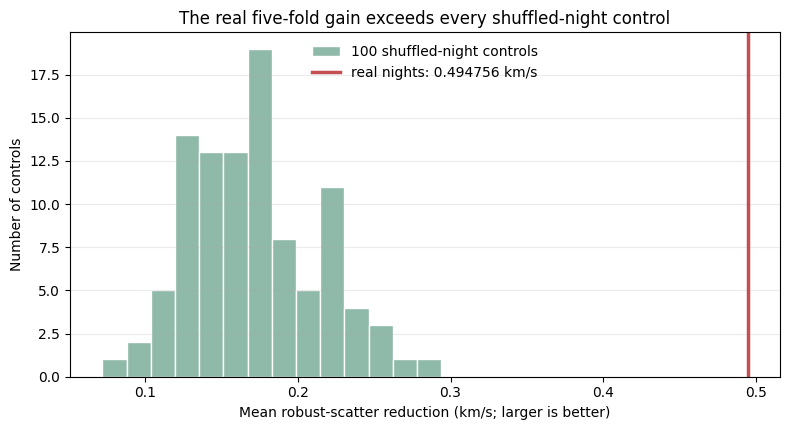

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(
    control_mean_gains,
    bins=14,
    color="#8FB9A8",
    edgecolor="white",
    label="100 shuffled-night controls",
)
ax.axvline(
    real_mean_gain,
    color="#C44E52",
    linewidth=2.5,
    label=f"real nights: {real_mean_gain:.6f} km/s",
)
ax.set(
    title="The real five-fold gain exceeds every shuffled-night control",
    xlabel="Mean robust-scatter reduction (km/s; larger is better)",
    ylabel="Number of controls",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


The controls can still show positive gains because a flexible fit
can absorb some chance structure. The relevant result is therefore
not “controls equal zero”; it is that the real-night gain lies well
beyond the complete recorded control range. With a finite control
set, the add-one rule reports `1/101`, never zero.

### 2. Descriptive context and sensitivity

The left panel below describes which program pairs contribute more
or less gain; it is not a set of separately preregistered claims.
The right panel checks that changing the maximum number of epoch
pairs contributed by one source leaves the aggregate result near
0.5 km/s.


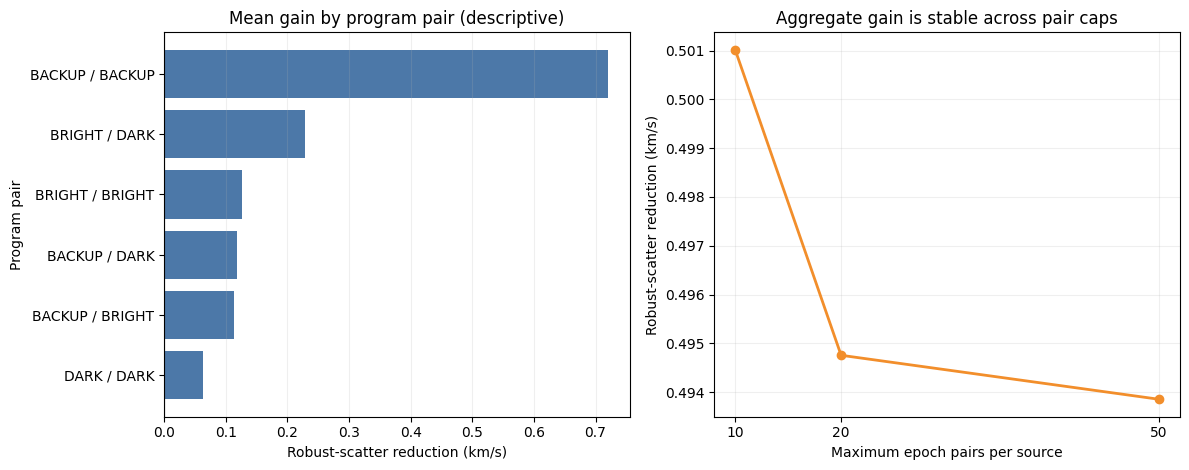

In [4]:
by_program = datasets["by_program"].copy()
by_program["GAIN_KMS"] = (
    by_program["RAW_WIDTH_BEFORE_KMS"]
    - by_program["RAW_WIDTH_AFTER_KMS"]
)
program_pair_gain = (
    by_program.groupby("PROGRAM_PAIR", sort=False)["GAIN_KMS"]
    .mean()
    .sort_values()
)
cap_view = pair_cap_sensitivity.sort_values("MAX_PAIRS_PER_SOURCE")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].barh(
    program_pair_gain.index,
    program_pair_gain.values,
    color="#4C78A8",
)
axes[0].axvline(0, color="#555555", linewidth=0.8)
axes[0].set(
    title="Mean gain by program pair (descriptive)",
    xlabel="Robust-scatter reduction (km/s)",
    ylabel="Program pair",
)
axes[0].grid(axis="x", alpha=0.2)

axes[1].plot(
    cap_view["MAX_PAIRS_PER_SOURCE"],
    cap_view["RAW_WIDTH_DELTA_KMS"],
    marker="o",
    color="#F28E2B",
    linewidth=2,
)
axes[1].set(
    title="Aggregate gain is stable across pair caps",
    xlabel="Maximum epoch pairs per source",
    ylabel="Robust-scatter reduction (km/s)",
    xticks=cap_view["MAX_PAIRS_PER_SOURCE"].tolist(),
)
axes[1].grid(alpha=0.2)
fig.tight_layout()
plt.show()


In [5]:
replication_view = reproducibility_by_program.loc[
    :,
    [
        "SCOPE",
        "N_COMMON_LABELS",
        "OFFSET_CORRELATION",
        "OFFSET_SLOPE_B_ON_A",
        "MEDIAN_ABS_DIFF_KMS",
    ],
].copy()
replication_view["OFFSET_CORRELATION"] = replication_view[
    "OFFSET_CORRELATION"
].round(5)
replication_view["OFFSET_SLOPE_B_ON_A"] = replication_view[
    "OFFSET_SLOPE_B_ON_A"
].round(5)
replication_view["MEDIAN_ABS_DIFF_KMS"] = replication_view[
    "MEDIAN_ABS_DIFF_KMS"
].round(5)
replication_view


,SCOPE,N_COMMON_LABELS,OFFSET_CORRELATION,OFFSET_SLOPE_B_ON_A,MEDIAN_ABS_DIFF_KMS
0,ALL,483,0.98026,1.00157,0.10692
1,ALL_WITHIN_PROGRAM_DEMEANED,483,0.97672,0.99465,0.11943
2,PROGRAM:BACKUP,83,0.99892,0.99527,0.04813
3,PROGRAM:BRIGHT,228,0.95465,0.99213,0.09791
4,PROGRAM:DARK,172,0.88397,1.00340,0.16203


## Takeaways

1. **BASELINE-NIGHT is supported:** the real mean gain is larger
   than all 100 shuffled-night controls under the recorded design.
2. **BASELINE-REPLICATION is supported:** separately estimated
   disjoint-source-half offsets agree closely (`r = 0.98026`, slope
   near 1).
3. The pair-cap check shows similar aggregate gains across the three
   committed caps, reducing concern that a few heavily repeated
   stars alone set the result.
4. The boundary matters: these are relative diagnostic offsets for
   represented nights. They are neither a causal diagnosis nor a
   ready-to-apply DESI correction.
